In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel
from numba import njit
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, leaves_list
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
import geopandas as gpd
import numpy as np
from cmdstanpy import CmdStanModel
from sklearn.preprocessing import StandardScaler
from numba import njit
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, leaves_list
from sklearn.cluster import AgglomerativeClustering
import itertools
import os
import pickle
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')



In [2]:
df = gpd.read_file('../data/updated_data.geojson')

In [3]:
y = df["fem_empl_rate"].to_numpy()
y = y / 100
y_star = np.log(y / (1 - y))

# selected_covariates = ['fem_house_rate', 'fertility_rate', 'GDP', 'young_neet', 'internet_coverage_rate', 'coverage', 'public_coverage', 'per_capita_public_expenditure', 'other_percapita_public_expenditure', 'other_percapita_user_contrib', 'ecec_diffusion']
selected_covariates = ['private_coverage', 'public_coverage', 'graduate_mobility_rate', 'fem_edu_rate']

X = df[selected_covariates].to_numpy()
X_scaler = StandardScaler()
X_star = X_scaler.fit_transform(X)

N = 107 
P = len(selected_covariates) 

In [4]:
df = df.reset_index(drop=True)

n = len(df)
node1 = []
node2 = []
num_neighbors = np.zeros(n, dtype=int)

sindex = df.sindex  # spatial index

for i, geom in enumerate(df.geometry):
    # candidates using bounding boxes
    possible_matches = list(sindex.intersection(geom.bounds))

    for j in possible_matches:
        if j <= i:
            continue
        if geom.touches(df.geometry[j]):
            node1.append(i + 1)   # Stan is 1-based
            node2.append(j + 1)

            num_neighbors[i] += 1
            num_neighbors[j] += 1

node1 = np.asarray(node1, dtype=int)
node2 = np.asarray(node2, dtype=int)

W = np.zeros((n, n), dtype=int)

for i, j in zip(node1 - 1, node2 - 1):
    W[i, j] = 1
    W[j, i] = 1

In [5]:
model = """
functions {
  real car_leroux_lpdf(
    vector phi,
    real tau2,
    real rho,
    matrix W,
    vector D,
    vector lambda,
    int N
  ) {
    vector[N] Dphi;
    vector[N] Wphi;
    vector[N] det_terms;
    real quad;

    Dphi = D .* phi;        // D * phi
    Wphi = W * phi;         // W * phi

    for (i in 1 : N) {
      det_terms[i] = log(rho * lambda[i] + (1 - rho)); // eigenvalues of D-W
    }

    quad = rho * (dot_product(phi, Dphi) - dot_product(phi, Wphi)) + (1 - rho) * dot_product(phi, phi);

    return 0.5 * (
      N * log(tau2)
      + sum(det_terms)  
      - tau2 * quad
    );
  }
}

data {
  int<lower=1> N;          
  int<lower=1> P;                   
  vector[N] y_star;             
  matrix[N, P] X_star;           
  matrix<lower=0, upper=1>[N, N] W;       
}

transformed data {
  vector[N] D;            // diagonal entries of D
  vector[N] lambda;       // eigenvalues of D-W

  for (i in 1:N)
    D[i] = sum(W[i]);

  lambda = eigenvalues_sym(diag_matrix(D) - W);      // eigenvalues
}

parameters {          
  real alpha;         
  vector[P] beta; 
  real<lower=1e-6> sigma; 
  real<lower=1e-6> tau2;                  // CAR precision
  vector[N] phi_raw;                        // Spatial random effects
  real<lower=0, upper=0.95> rho;      // Leroux dependence parameter
}

transformed parameters {
  vector[N] phi;
  phi = phi_raw - mean(phi_raw);
}


model {

  tau2  ~ inv_gamma(2, 1);
  rho   ~ beta(1,1);
  sigma ~ inv_gamma(2, 1);
  
  alpha ~ normal(0, 2);

  for (j in 1:P) {
    beta[j] ~ normal(0, 1);
  }

  phi_raw ~ car_leroux(tau2, rho, W, D, lambda, N);

  // Likelihood
  for (i in 1:N) {
    real lps;
    real mu_i;
    mu_i = alpha + dot_product(row(X_star, i), beta) + phi[i];
    lps = normal_lpdf(y_star[i] | mu_i, sigma);
    target += lps;
  }
}

"""

In [6]:
with open("final_model_nomix.stan", "w") as f:
    f.write(model)

In [7]:
data = {
    "N": int(N),
    "P": int(P),
    "y_star": y_star.astype(float),
    "X_star": X_star.astype(float),
    "W": W,
}

In [8]:
model_exe = CmdStanModel(stan_file="final_model_nomix.stan")

22:09:48 - cmdstanpy - INFO - compiling stan file C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\final_model_nomix.stan to exe file C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\final_model_nomix.exe
22:12:49 - cmdstanpy - INFO - compiled model executable: C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\final_model_nomix.exe


In [9]:
fit = model_exe.sample(
    data=data,
    chains=4,
    iter_warmup=2000,
    iter_sampling=2000,
    adapt_delta=0.99,
    max_treedepth=15
)

22:12:50 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

22:13:00 - cmdstanpy - INFO - CmdStan done processing.


In [10]:
fit.column_names

('lp__',
 'accept_stat__',
 'stepsize__',
 'treedepth__',
 'n_leapfrog__',
 'divergent__',
 'energy__',
 'alpha',
 'beta[1]',
 'beta[2]',
 'beta[3]',
 'beta[4]',
 'sigma',
 'tau2',
 'phi_raw[1]',
 'phi_raw[2]',
 'phi_raw[3]',
 'phi_raw[4]',
 'phi_raw[5]',
 'phi_raw[6]',
 'phi_raw[7]',
 'phi_raw[8]',
 'phi_raw[9]',
 'phi_raw[10]',
 'phi_raw[11]',
 'phi_raw[12]',
 'phi_raw[13]',
 'phi_raw[14]',
 'phi_raw[15]',
 'phi_raw[16]',
 'phi_raw[17]',
 'phi_raw[18]',
 'phi_raw[19]',
 'phi_raw[20]',
 'phi_raw[21]',
 'phi_raw[22]',
 'phi_raw[23]',
 'phi_raw[24]',
 'phi_raw[25]',
 'phi_raw[26]',
 'phi_raw[27]',
 'phi_raw[28]',
 'phi_raw[29]',
 'phi_raw[30]',
 'phi_raw[31]',
 'phi_raw[32]',
 'phi_raw[33]',
 'phi_raw[34]',
 'phi_raw[35]',
 'phi_raw[36]',
 'phi_raw[37]',
 'phi_raw[38]',
 'phi_raw[39]',
 'phi_raw[40]',
 'phi_raw[41]',
 'phi_raw[42]',
 'phi_raw[43]',
 'phi_raw[44]',
 'phi_raw[45]',
 'phi_raw[46]',
 'phi_raw[47]',
 'phi_raw[48]',
 'phi_raw[49]',
 'phi_raw[50]',
 'phi_raw[51]',
 'phi_raw[52

           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha     0.053  0.012   0.030    0.077      0.000    0.000    7958.0   
beta[0]   0.071  0.028   0.021    0.125      0.001    0.000    1678.0   
beta[1]   0.136  0.026   0.086    0.184      0.001    0.000    1067.0   
beta[2]   0.183  0.047   0.098    0.277      0.002    0.001     559.0   
beta[3]  -0.020  0.032  -0.084    0.038      0.001    0.001     747.0   
...         ...    ...     ...      ...        ...      ...       ...   
phi[103]  0.150  0.092  -0.031    0.317      0.001    0.001    3983.0   
phi[104] -0.458  0.139  -0.719   -0.195      0.004    0.002     978.0   
phi[105] -0.211  0.124  -0.436    0.023      0.002    0.001    2783.0   
phi[106]  0.052  0.096  -0.125    0.231      0.002    0.001    2927.0   
rho       0.911  0.048   0.833    0.950      0.001    0.002    1571.0   

          ess_tail  r_hat  
alpha       5150.0    1.0  
beta[0]     3534.0    1.0  
beta[1]     2667.0    1.0  
beta[2]    

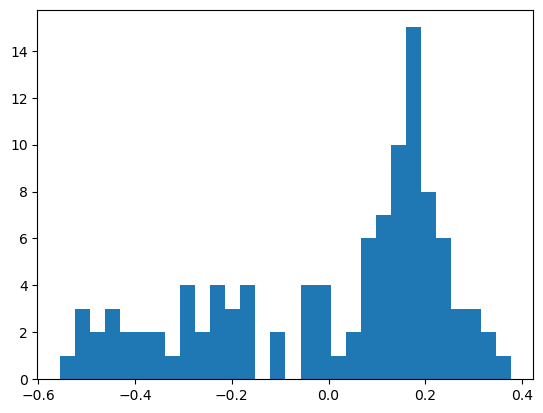

In [11]:
summary_95 = az.summary(fit, var_names=["alpha", "beta", "phi", "rho"])
print(summary_95)
phi_mean = summary_95.loc[summary_95.index.str.startswith("phi"), "mean"].values
plt.hist(phi_mean, bins=30)

betas_mean = summary_95.loc[summary_95.index.str.startswith("beta"), "mean"].values

In [12]:
betas_mean

array([ 0.071,  0.136,  0.183, -0.02 ])

In [17]:
summary_alpha_beta = az.summary(fit, var_names=["alpha", "beta"])
summary_alpha_beta = pd.DataFrame(summary_alpha_beta)
print(summary_alpha_beta)

          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha    0.053  0.012   0.030    0.077      0.000    0.000    7958.0   
beta[0]  0.071  0.028   0.021    0.125      0.001    0.000    1678.0   
beta[1]  0.136  0.026   0.086    0.184      0.001    0.000    1067.0   
beta[2]  0.183  0.047   0.098    0.277      0.002    0.001     559.0   
beta[3] -0.020  0.032  -0.084    0.038      0.001    0.001     747.0   

         ess_tail  r_hat  
alpha      5150.0    1.0  
beta[0]    3534.0    1.0  
beta[1]    2667.0    1.0  
beta[2]    1113.0    1.0  
beta[3]    1406.0    1.0  


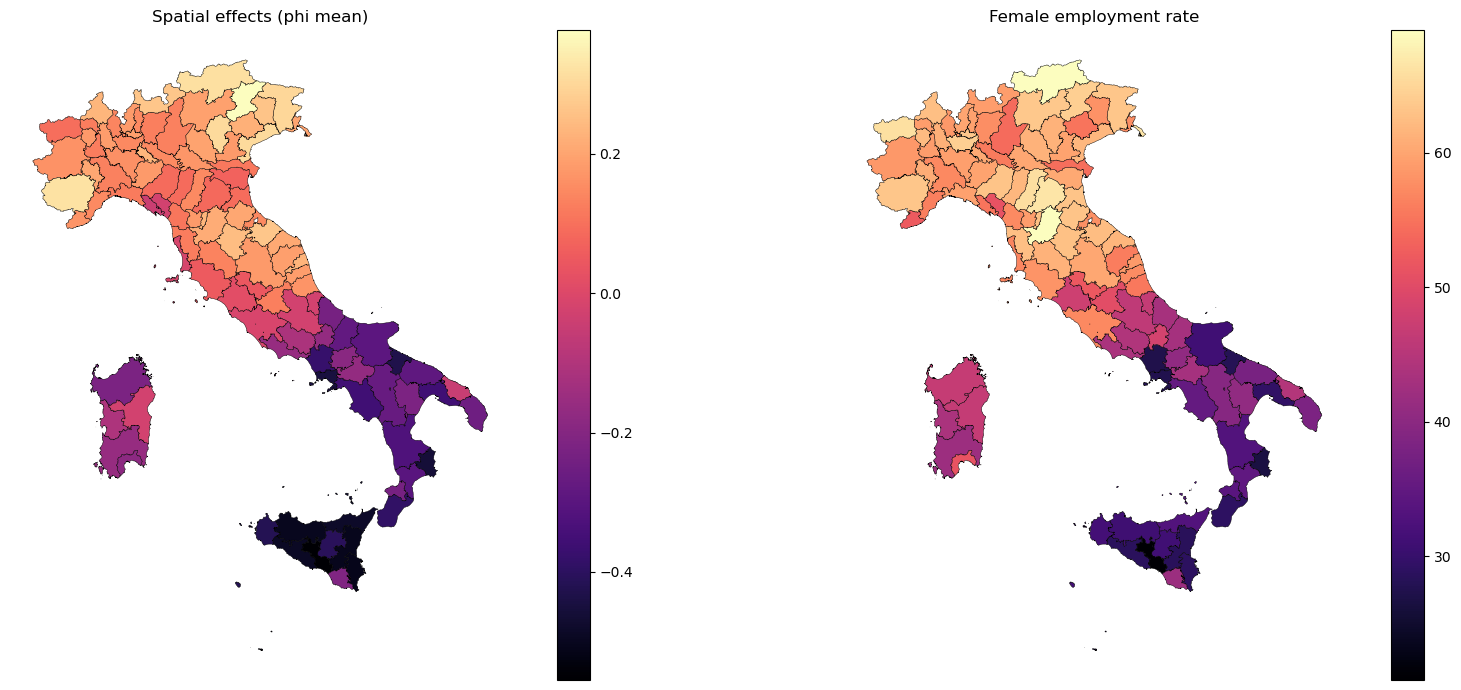

In [31]:
import geopandas as gpd

# gdf: GeoDataFrame with one row per observation/region
# must have a geometry column of polygons/multipolygons
gdf = gpd.read_file("../data/updated_data.geojson")
gdf["phi_mean"] = phi_mean

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

gdf.plot(column="phi_mean", categorical=False, legend=True, ax=ax1, cmap="magma", edgecolor="black", linewidth=0.3)
ax1.set_title("Spatial effects (phi mean)")
ax1.set_axis_off()

gdf.plot(column="fem_empl_rate", categorical=False, legend=True, ax=ax2, cmap="magma", edgecolor="black", linewidth=0.3)
ax2.set_title("Female employment rate")
ax2.set_axis_off()

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

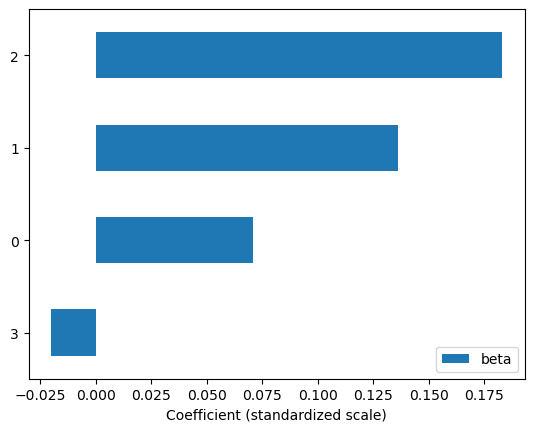

In [15]:
plt.figure(figsize=(8,6))
pd.DataFrame(betas_mean, columns=['beta']).sort_values(by='beta').plot(kind='barh')
plt.xlabel('Coefficient (standardized scale)')
plt.show()

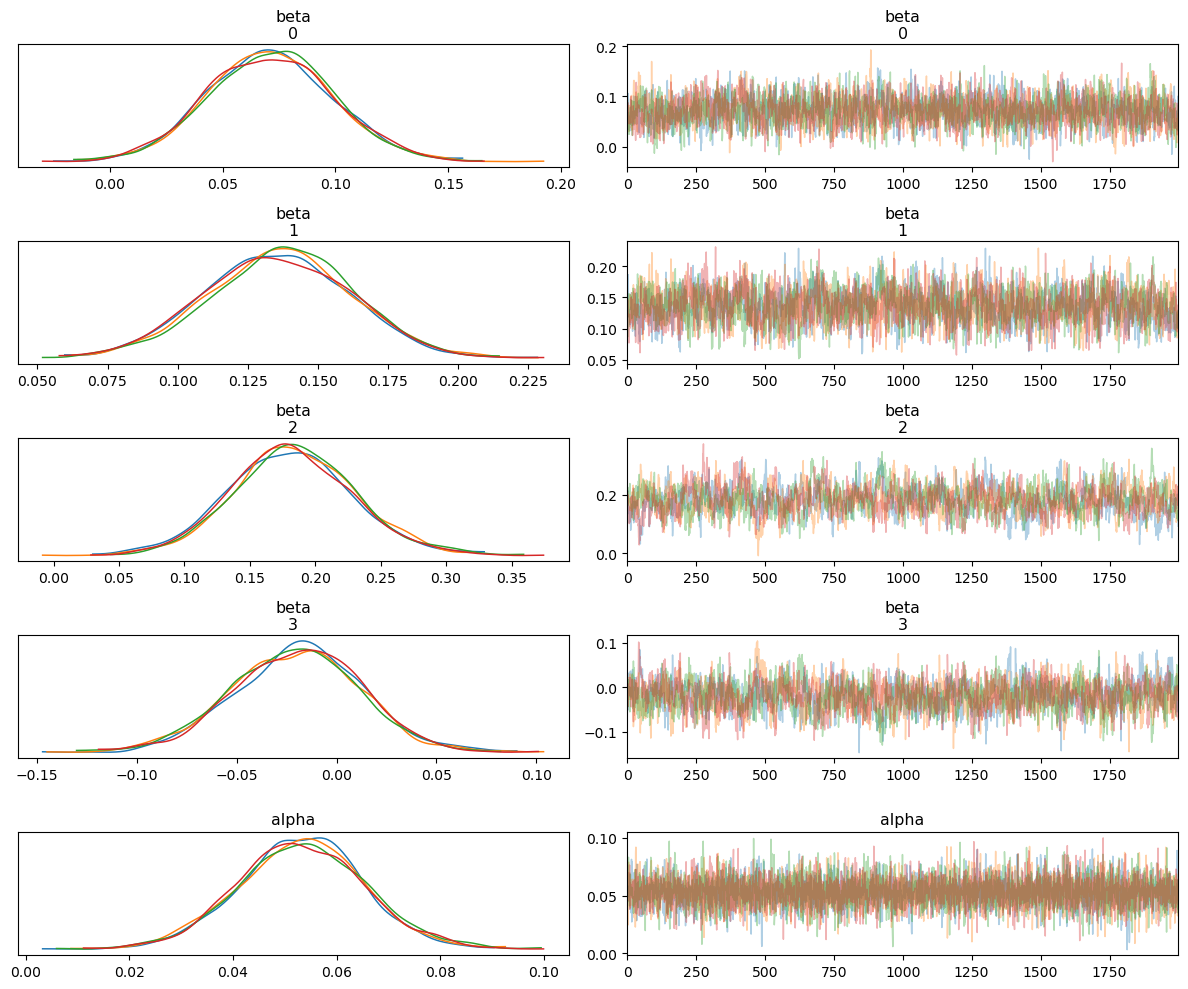

In [16]:
az.rcParams["plot.max_subplots"] = 100   
az.plot_trace(fit, var_names=["beta", "alpha"], compact=False)
plt.tight_layout()

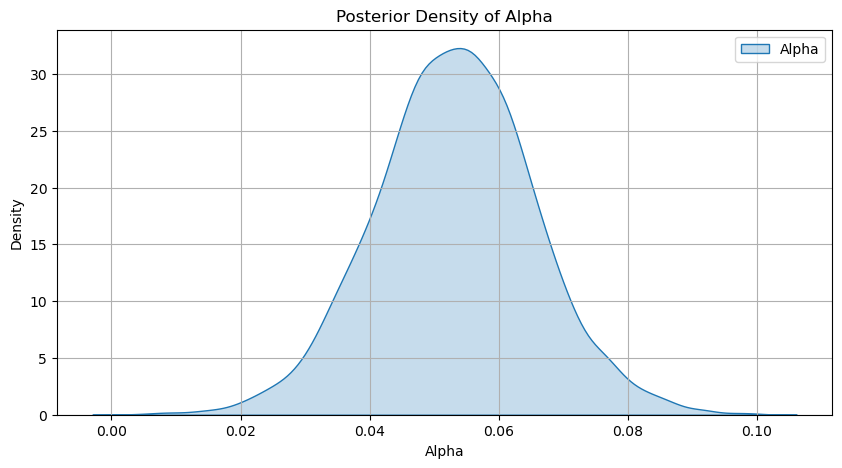

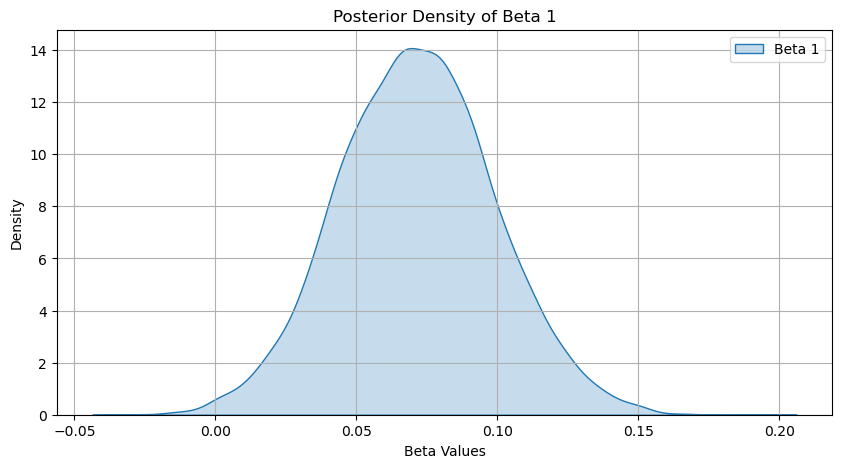

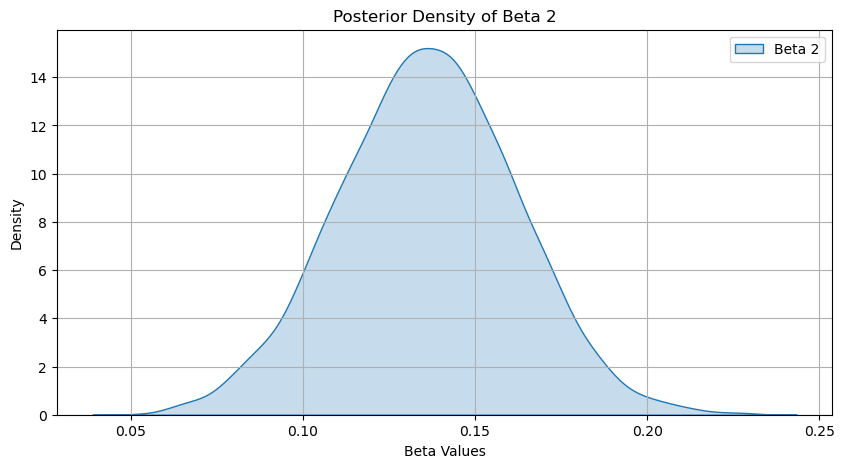

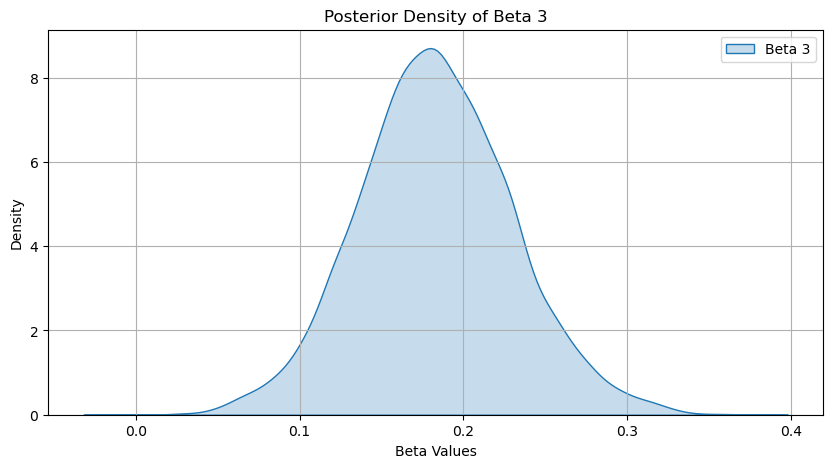

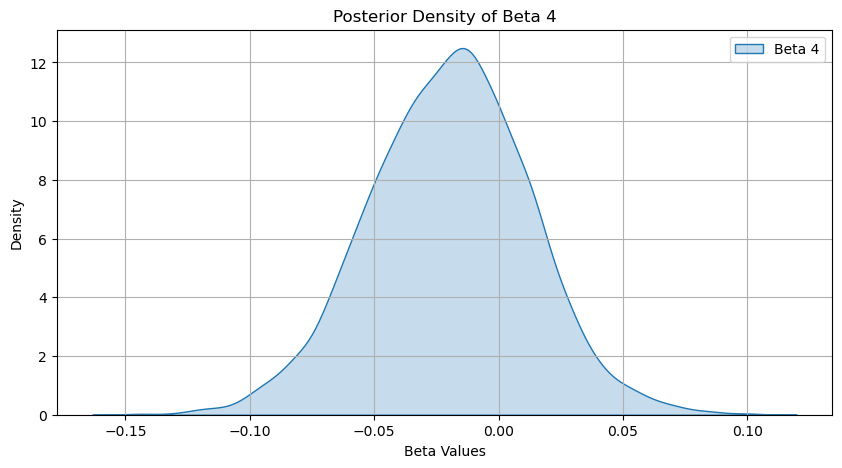

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Extract posterior samples for alpha and betas
posterior_alpha = fit.stan_variable('alpha')
posterior_betas = fit.stan_variable('beta')

# Plot KDE for alpha
plt.figure(figsize=(10, 5))
sns.kdeplot(posterior_alpha, fill=True, label='Alpha')
plt.title('Posterior Density of Alpha')
plt.xlabel('Alpha')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

# Plot KDE for each beta in separate diagrams
for i in range(posterior_betas.shape[1]):
    plt.figure(figsize=(10, 5))
    sns.kdeplot(posterior_betas[:, i], fill=True, label=f'Beta {i+1}')
    plt.title(f'Posterior Density of Beta {i+1}')
    plt.xlabel('Beta Values')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.show()